In [1]:
# V9-01 — load structural ROIs and collapse duplicates on roi_dir

from pathlib import Path
import pandas as pd
import numpy as np
import re

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 120)

ROOT = Path("/Users/davekokel/Projects/carp_v2")
BASE = ROOT / "seed_kits" / "legacy_wrangling_v2"
RAW  = BASE / "raw"
WORK = BASE / "working"

STRUCT_PATH = WORK / "output_from_linking_v5.csv"

print("V9-01 — ROOT:      ", ROOT)
print("V9-01 — STRUCT_PATH:", STRUCT_PATH)

if not STRUCT_PATH.exists():
    raise FileNotFoundError(f"V9-01: structural CSV not found at {STRUCT_PATH}")

df_struct_raw = pd.read_csv(STRUCT_PATH)

print("\nV9-01 — df_struct_raw shape:", df_struct_raw.shape)
print("V9-01 — df_struct_raw columns:")
print(list(df_struct_raw.columns))

print("\nV9-01 — basic ROI QC (raw):")
print("  total rows:      ", len(df_struct_raw))
print("  unique roi_dir:  ", df_struct_raw["roi_dir"].nunique())
print("  dup roi_dir rows:", df_struct_raw.duplicated("roi_dir").sum())

# ── collapse duplicate roi_dir rows by union of imaging text ─────────────────

def _norm_str(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    return s or None

imaging_cols_to_union = [
    "additional mRNAs injected",
    "additional plasmids injected",
    "additonal proteins injected",
    "additonal dye and chemicals",
    "Unique Targets with blanks",
]

def _union_pipe(values):
    vals = []
    for v in values:
        if pd.isna(v):
            continue
        s = str(v).strip()
        if not s:
            continue
        parts = re.split(r"[|,]", s)
        for p in parts:
            p = p.strip()
            if p:
                vals.append(p)
    if not vals:
        return pd.NA
    uniq = []
    seen = set()
    for v in vals:
        if v not in seen:
            seen.add(v)
            uniq.append(v)
    return "|".join(uniq)

group_cols = [c for c in df_struct_raw.columns if c not in imaging_cols_to_union]

# first, sort for deterministic behavior
df_struct_raw = df_struct_raw.sort_values(["roi_dir"]).reset_index(drop=True)

# aggregate imaging text per roi_dir
agg_dict = {c: ("first") for c in group_cols}
for c in imaging_cols_to_union:
    agg_dict[c] = _union_pipe

df_struct = (
    df_struct_raw
    .groupby("roi_dir", dropna=False, as_index=False)
    .agg(agg_dict)
)

print("\nV9-01 — df_struct AFTER collapse:")
print("  total rows:", len(df_struct))
print("  unique roi_dir:", df_struct["roi_dir"].nunique())

# seed treatment_*_names_sheet from imaging columns
df_struct["treatment_rna_names_sheet"] = df_struct["additional mRNAs injected"].astype("string")
df_struct["treatment_plasmid_names_sheet"] = df_struct["additional plasmids injected"].astype("string")

# normalize dataset_slug_norm for later joins
def _norm_slug(s):
    if pd.isna(s):
        return None
    return str(s).strip()

if "dataset_slug" not in df_struct.columns:
    raise KeyError("V9-01: df_struct missing dataset_slug; check linking output.")

df_struct["dataset_slug_norm"] = df_struct["dataset_slug"].apply(_norm_slug)

print("\nV9-01 — sample rows after collapse/seed:")
print(
    df_struct[
        [
            "roi_dir",
            "dataset_slug",
            "treatment_rna_names_sheet",
            "treatment_plasmid_names_sheet",
            "Unique Targets with blanks",
        ]
    ].head(10)
)

# keep as df_enrich for subsequent steps
df_enrich = df_struct.copy()

V9-01 — ROOT:       /Users/davekokel/Projects/carp_v2
V9-01 — STRUCT_PATH: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/working/output_from_linking_v5.csv

V9-01 — df_struct_raw shape: (1082, 46)
V9-01 — df_struct_raw columns:
['date_experiment', 'fish', 'roi_rel', 'roi_name', 'roi_tiffs', 'roi_dir', 'dataset', 'experiment_folder', 'roi_path_date_yyyymmdd', 'fish_folder', 'roi_folder', 'fish_id', 'fish_number', 'fish_age_hpf', 'fish_nickname', 'fish_raw_norm', 'roi_anatomy_tokens', 'roi_anatomy', 'fish_folder_patched', 'dataset_slug', 'dataset_slug_norm', 'sheet_slug_norm', 'date_mount_yyyymmdd', 'date_mount', 'Date imaged', 'mount_id', 'ZF female genotype', 'ZF male genotype', 'additional plasmids injected', 'additional mRNAs injected', 'additonal proteins injected', 'additonal dye and chemicals', 'Date born', 'Imaged Locations', 'Unique Targets with blanks', 'Unique Targets', 'Data location', 'link_source', 'plate_date', 'mount_id_inferred', 'mount_id_source', 'pla

In [2]:
# V9-02 — load catalogs, build parent_slug_agg, rna_map, plasmid_map, constructs_ft

import pandas as pd
import numpy as np

# paths
PARENT_MAP_XLSX = RAW / "Unique_parent_names__mom_dad_combined__preview_dqm_v5.xlsx"
PARENT_MAP_CSV  = RAW / "Unique_parent_names__mom_dad_combined__preview_dqm_v5.csv"
INJECTED_RNA    = RAW / "Unique_injected_rna__preview_dqm.xlsx"
INJECTED_PLASMID= RAW / "Unique_injected_plasmid__preview_dqm.xlsx"

AUTO = ROOT / "seed_kits" / "2025-11-15-121231-autoload"
CONSTRUCTS_PATH = AUTO / "constructs_plasmid.csv"
TAGS_PATH       = AUTO / "tags.xlsx"
ALIAS_PATH      = AUTO / "alias.csv"

print("V9-02 — PARENT_MAP_XLSX:", PARENT_MAP_XLSX)
print("V9-02 — PARENT_MAP_CSV: ", PARENT_MAP_CSV)
print("V9-02 — INJECTED_RNA:   ", INJECTED_RNA)
print("V9-02 — INJECTED_PLASMID:", INJECTED_PLASMID)
print("V9-02 — CONSTRUCTS_PATH:", CONSTRUCTS_PATH)
print("V9-02 — TAGS_PATH:      ", TAGS_PATH)
print("V9-02 — ALIAS_PATH:     ", ALIAS_PATH)

# parent_map: prefer CSV v5, fall back to XLSX
if PARENT_MAP_CSV.exists():
    parent_map = pd.read_csv(PARENT_MAP_CSV)
    print("V9-02 — parent_map loaded from CSV")
elif PARENT_MAP_XLSX.exists():
    parent_map = pd.read_excel(PARENT_MAP_XLSX)
    print("V9-02 — parent_map loaded from XLSX")
else:
    raise FileNotFoundError("V9-02: parent map v5 not found in RAW.")

# other catalogs
if not INJECTED_RNA.exists():
    raise FileNotFoundError(f"V9-02: missing injected_rna at {INJECTED_RNA}")
if not INJECTED_PLASMID.exists():
    raise FileNotFoundError(f"V9-02: missing injected_plasmid at {INJECTED_PLASMID}")
if not CONSTRUCTS_PATH.exists():
    raise FileNotFoundError(f"V9-02: missing constructs_plasmid at {CONSTRUCTS_PATH}")
if not TAGS_PATH.exists():
    raise FileNotFoundError(f"V9-02: missing tags.xlsx at {TAGS_PATH}")
if not ALIAS_PATH.exists():
    raise FileNotFoundError(f"V9-02: missing alias.csv at {ALIAS_PATH}")

injected_rna     = pd.read_excel(INJECTED_RNA)
injected_plasmid = pd.read_excel(INJECTED_PLASMID)
constructs       = pd.read_csv(CONSTRUCTS_PATH)
tags_cat         = pd.read_excel(TAGS_PATH)
alias            = pd.read_csv(ALIAS_PATH)

print("\nV9-02 — shapes:")
print("  parent_map:      ", parent_map.shape)
print("  injected_rna:    ", injected_rna.shape)
print("  injected_plasmid:", injected_plasmid.shape)
print("  constructs:      ", constructs.shape)
print("  tags_cat:        ", tags_cat.shape)
print("  alias:           ", alias.shape)

# normalize parent_map columns
parent_cols_norm = {
    "parent_fish_name": "parent_fish_name",
    "parent_name": "parent_fish_name",
    "plasmid_base_code": "plasmid_base_code",
    "allele": "allele",
    "injected_rna": "injected_rna",
    "injected plasmid": "injected_plasmid",
    "injected_plasmid": "injected_plasmid",
}
parent_map = parent_map.rename(columns={k: v for k, v in parent_cols_norm.items() if k in parent_map.columns})

needed_parent_cols = ["parent_fish_name", "plasmid_base_code", "allele", "injected_rna", "injected_plasmid"]
missing_parent_cols = [c for c in needed_parent_cols if c not in parent_map.columns]
if missing_parent_cols:
    raise KeyError(f"V9-02: parent_map missing columns: {missing_parent_cols}")

print("\nV9-02 — parent_map columns:", list(parent_map.columns))
print("V9-02 — injected_rna columns:", list(injected_rna.columns))
print("V9-02 — injected_plasmid columns:", list(injected_plasmid.columns))

# helper to normalize labels
def _norm_label(s):
    if pd.isna(s):
        return None
    s = str(s).strip().lower()
    s = re.sub(r"^\d{8}[_-]", "", s)
    s = re.sub(r"\(.*?\)", "", s)
    s = re.sub(r"[^a-z0-9]+", "", s)
    s = s.strip()
    return s or None

# parent_slug_agg
parent_map = parent_map.copy()
parent_map["parent_slug_norm"] = parent_map["parent_fish_name"].apply(_norm_label)

def _agg_nonempty(series: pd.Series) -> str | None:
    vals = [
        str(x).strip()
        for x in series
        if pd.notna(x) and str(x).strip() not in ("", "nan", "n/a", "na")
    ]
    if not vals:
        return None
    seen = set()
    out = []
    for v in vals:
        if v not in seen:
            seen.add(v)
            out.append(v)
    return "|".join(out)

parent_slug_agg = (
    parent_map
    .groupby("parent_slug_norm", dropna=True)
    .agg({
        "plasmid_base_code": _agg_nonempty,
        "allele": _agg_nonempty,
        "injected_rna": _agg_nonempty,
        "injected_plasmid": _agg_nonempty,
    })
    .reset_index()
    .rename(columns={
        "plasmid_base_code": "geno_base_codes_v9_map",
        "allele": "geno_alleles_v9_map",
        "injected_rna": "inj_rna_names_v9_map",
        "injected_plasmid": "inj_plasmid_names_v9_map",
    })
)

print("\nV9-02 — parent_slug_agg sample:")
print(parent_slug_agg.head(20))

# build rna_map / plasmid_map
def _norm_treatment_name(s):
    if pd.isna(s):
        return None
    s = str(s).strip()
    return s or None

rna_df = injected_rna.copy()
if not {"injected_rna", "plasmid_base_code"} <= set(rna_df.columns):
    raise KeyError("V9-02: injected_rna missing required columns.")

rna_map = (
    rna_df[["injected_rna", "plasmid_base_code"]]
    .rename(columns={"injected_rna": "treatment_name", "plasmid_base_code": "rna_base_code"})
    .dropna(subset=["treatment_name", "rna_base_code"])
)
rna_map["treatment_name_norm"] = rna_map["treatment_name"].apply(_norm_treatment_name)
rna_map = rna_map.drop_duplicates("treatment_name_norm")

pl_df = injected_plasmid.copy()
if not {"injected_plasmid", "plasmid_base_code"} <= set(pl_df.columns):
    raise KeyError("V9-02: injected_plasmid missing required columns.")

plasmid_map = (
    pl_df[["injected_plasmid", "plasmid_base_code"]]
    .rename(columns={"injected_plasmid": "treatment_name", "plasmid_base_code": "plasmid_base_code"})
    .dropna(subset=["treatment_name", "plasmid_base_code"])
)
plasmid_map["treatment_name_norm"] = plasmid_map["treatment_name"].apply(_norm_treatment_name)
plasmid_map = plasmid_map.drop_duplicates("treatment_name_norm")

print("\nV9-02 — rna_map sample:")
print(rna_map.head(10))

print("\nV9-02 — plasmid_map sample:")
print(plasmid_map.head(10))

# build constructs_ft: plasmid_code → fluor, tag, localization

constructs_ft = constructs.copy()

# merge tag_localization if constructs has tag_codes and tags_cat has localization
if "tag_code" in constructs_ft.columns:
    # ensure tags_cat has nickname + localization
    if "nickname" in tags_cat.columns and "localization" in tags_cat.columns:
        tags_small = tags_cat[["nickname", "localization"]].rename(columns={"nickname": "tag_code", "localization": "tag_localization"})
        constructs_ft = constructs_ft.merge(tags_small, on="tag_code", how="left")
else:
    constructs_ft["tag_code"] = pd.NA
    constructs_ft["tag_localization"] = pd.NA

# ensure tag_localization is filled (untagged = cytosol)
if "tag_localization" not in constructs_ft.columns:
    constructs_ft["tag_localization"] = pd.NA

mask_missing_loc = constructs_ft["tag_localization"].isna() | (constructs_ft["tag_localization"].astype(str).str.strip() == "")
constructs_ft.loc[mask_missing_loc, "tag_localization"] = "cytosol"

# ensure we have plasmid_code, fluor_code
if "plasmid_code" not in constructs_ft.columns:
    raise KeyError("V9-02: constructs_ft missing plasmid_code; check constructs_plasmid.csv.")
if "fluor_code" not in constructs_ft.columns:
    raise KeyError("V9-02: constructs_ft missing fluor_code; check constructs_plasmid.csv.")

constructs_ft = constructs_ft[["plasmid_code", "fluor_code", "tag_code", "tag_localization"]].copy()

print("\nV9-02 — constructs_ft sample:")
print(constructs_ft.head(20))

# keep for later cells

V9-02 — PARENT_MAP_XLSX: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/raw/Unique_parent_names__mom_dad_combined__preview_dqm_v5.xlsx
V9-02 — PARENT_MAP_CSV:  /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/raw/Unique_parent_names__mom_dad_combined__preview_dqm_v5.csv
V9-02 — INJECTED_RNA:    /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/raw/Unique_injected_rna__preview_dqm.xlsx
V9-02 — INJECTED_PLASMID: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/raw/Unique_injected_plasmid__preview_dqm.xlsx
V9-02 — CONSTRUCTS_PATH: /Users/davekokel/Projects/carp_v2/seed_kits/2025-11-15-121231-autoload/constructs_plasmid.csv
V9-02 — TAGS_PATH:       /Users/davekokel/Projects/carp_v2/seed_kits/2025-11-15-121231-autoload/tags.xlsx
V9-02 — ALIAS_PATH:      /Users/davekokel/Projects/carp_v2/seed_kits/2025-11-15-121231-autoload/alias.csv
V9-02 — parent_map loaded from CSV

V9-02 — shapes:
  parent_map:       (52, 5)
  injected_rna:    

In [3]:
# V9-03 — slug-level genotype/treatment defaults (parents + experiment_hole_patch_v7)

EXP_PATCH_PATH = RAW / "experiment_hole_patch_v7.csv"
print("V9-03 — EXP_PATCH_PATH:", EXP_PATCH_PATH)

if not EXP_PATCH_PATH.exists():
    raise FileNotFoundError(f"V9-03: experiment hole patch CSV not found at {EXP_PATCH_PATH}")

exp_patch = pd.read_csv(EXP_PATCH_PATH)

required_cols = {
    "dataset_slug",
    "genotype_base_codes",
    "genotype_allele_codes",
    "treatment_rna_base_codes",
}
missing = required_cols - set(exp_patch.columns)
if missing:
    raise KeyError(f"V9-03: experiment_hole_patch_v7.csv missing columns: {sorted(missing)}")

def _norm_slug(s):
    if pd.isna(s):
        return None
    return str(s).strip()

exp_patch["dataset_slug_norm"] = exp_patch["dataset_slug"].apply(_norm_slug)

# aggregate exp_patch per slug (union pipe)
def _union_codes(series: pd.Series) -> str | None:
    vals = []
    for v in series:
        if pd.isna(v):
            continue
        s = str(v).strip()
        if not s:
            continue
        parts = [p.strip() for p in re.split(r"[|,]", s) if p.strip()]
        vals.extend(parts)
    if not vals:
        return None
    seen = set()
    out = []
    for v in vals:
        if v not in seen:
            seen.add(v)
            out.append(v)
    return "|".join(out)

exp_slug_agg = (
    exp_patch
    .groupby("dataset_slug_norm", dropna=True)
    .agg({
        "genotype_base_codes": _union_codes,
        "genotype_allele_codes": _union_codes,
        "treatment_rna_base_codes": _union_codes,
    })
    .reset_index()
    .rename(columns={
        "genotype_base_codes": "geno_base_codes_v9_exp",
        "genotype_allele_codes": "geno_alleles_v9_exp",
        "treatment_rna_base_codes": "treatment_rna_base_codes_v9_exp",
    })
)

print("\nV9-03 — exp_slug_agg sample:")
print(exp_slug_agg.head(20))

# build slug_basecode_map by merging parent_slug_agg + exp_slug_agg
# normalize slugs on df_enrich side first
df_enrich = df_enrich.copy()
df_enrich["dataset_slug_norm"] = df_enrich["dataset_slug_norm"].apply(_norm_slug)

# build slug-level table of slugs present in df_enrich
slugs_present = pd.DataFrame({"dataset_slug_norm": sorted(df_enrich["dataset_slug_norm"].dropna().unique())})

# compute exp_slug_norm-like label for each slug to match parent_slug_norm logic
slugs_present["exp_slug_norm_label"] = slugs_present["dataset_slug_norm"].apply(_norm_label)

# join parent_slug_agg onto slugs_present
slug_parent = slugs_present.merge(
    parent_slug_agg,
    left_on="exp_slug_norm_label",
    right_on="parent_slug_norm",
    how="left",
)

# join exp_slug_agg (experiment-level overrides)
slug_full = slug_parent.merge(
    exp_slug_agg,
    on="dataset_slug_norm",
    how="left",
)

# final slug-level basecodes:
def _coalesce(a, b):
    # prefer b if not empty, else a
    if pd.notna(b) and str(b).strip() not in ("", "None", "nan", "<NA>"):
        return b
    return a

slug_full["genotype_base_codes_slug"] = [
    _coalesce(pb, eb) for pb, eb in zip(
        slug_full["geno_base_codes_v9_map"],
        slug_full["geno_base_codes_v9_exp"],
    )
]
slug_full["genotype_allele_codes_slug"] = [
    _coalesce(pa, ea) for pa, ea in zip(
        slug_full["geno_alleles_v9_map"],
        slug_full["geno_alleles_v9_exp"],
    )
]
slug_full["treatment_rna_base_codes_slug"] = [
    _coalesce(pr, er) for pr, er in zip(
        slug_full["inj_rna_names_v9_map"],   # NOTE: this is names, not basecodes, but exp_patch carries basecodes
        slug_full["treatment_rna_base_codes_v9_exp"],
    )
]

slug_basecode_map = slug_full[[
    "dataset_slug_norm",
    "genotype_base_codes_slug",
    "genotype_allele_codes_slug",
    "treatment_rna_base_codes_slug",
]].copy()

print("\nV9-03 — slug_basecode_map sample:")
print(slug_basecode_map.head(20))

# join slug_basecode_map onto df_enrich
df_enrich = df_enrich.merge(
    slug_basecode_map,
    on="dataset_slug_norm",
    how="left",
)

print("\nV9-03 — df_enrich after slug basecode join (sample):")
print(
    df_enrich[
        [
            "dataset_slug",
            "genotype_base_codes_slug",
            "genotype_allele_codes_slug",
            "treatment_rna_base_codes_slug",
        ]
    ].drop_duplicates().head(30)
)

V9-03 — EXP_PATCH_PATH: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/raw/experiment_hole_patch_v7.csv

V9-03 — exp_slug_agg sample:
                            dataset_slug_norm geno_base_codes_v9_exp geno_alleles_v9_exp treatment_rna_base_codes_v9_exp
0               20250521_skittles_no-membrane                pDQM034               309.0                            None
1                                20250602_mem                pDQM082               315.0                         MGCO-39
2              20250624_skittlez_Chris_x_Liam                pDQM034               309.0                            None
3               20250624_skittlez_Issac_x_Ken                pDQM034               309.0                            None
4   20250721_72hpf_mrna_mSG_organelle_LLS-SIM                   None                None                 MGCO-04|MGCO-01
5                   20250805_lifeact_mem-halo                   None                None                 MGCO-24|MGCO-39
6 

In [4]:
# V9-04 — final ROI-level basecodes from slug defaults + imaging text

df_enrich = df_enrich.copy()

# helper to split pipe/commas
def _split_codes(val):
    if pd.isna(val):
        return []
    s = str(val).strip()
    if not s:
        return []
    parts = [p.strip() for p in re.split(r"[|,]", s) if p.strip()]
    return parts

# row-level treatment mapping using rna_map/plasmid_map + direct basecodes
basecodes_known = set(rna_map["rna_base_code"].dropna().astype(str)) | \
                  set(plasmid_map["plasmid_base_code"].dropna().astype(str))

def _tokens_to_basecodes(name_str, mapping_df, basecode_col):
    out = []
    if pd.isna(name_str):
        return out
    s = str(name_str).strip()
    if not s:
        return out
    tokens = [t.strip() for t in re.split(r"[|,;]", s) if t.strip()]
    mapping = dict(zip(mapping_df["treatment_name_norm"], mapping_df[basecode_col]))
    for t in tokens:
        key = _norm_treatment_name(t)
        # direct mapping
        if key in mapping and pd.notna(mapping[key]):
            for v in _split_codes(mapping[key]):
                out.append(v)
        # direct basecode
        if t in basecodes_known:
            out.append(t)
    # uniq, preserve order
    seen = set()
    uniq = []
    for v in out:
        if v not in seen:
            seen.add(v)
            uniq.append(v)
    return uniq

row_rna_codes = []
row_plasmid_codes = []

for _, row in df_enrich[["treatment_rna_names_sheet", "treatment_plasmid_names_sheet"]].iterrows():
    row_rna_codes.append(
        _tokens_to_basecodes(row["treatment_rna_names_sheet"], rna_map, "rna_base_code")
    )
    row_plasmid_codes.append(
        _tokens_to_basecodes(row["treatment_plasmid_names_sheet"], plasmid_map, "plasmid_base_code")
    )

df_enrich["treatment_rna_codes_row"] = row_rna_codes
df_enrich["treatment_plasmid_codes_row"] = row_plasmid_codes

# combine slug-level and row-level treatment basecodes
final_rna_codes = []
final_plasmid_codes = []

for _, row in df_enrich[["treatment_rna_base_codes_slug", "treatment_rna_codes_row", "treatment_plasmid_codes_row"]].iterrows():
    # RNA
    slug_rna = _split_codes(row["treatment_rna_base_codes_slug"])
    row_rna  = row["treatment_rna_codes_row"] or []
    rna_all  = slug_rna + row_rna
    seen = set()
    rna_uniq = []
    for v in rna_all:
        if v not in seen:
            seen.add(v)
            rna_uniq.append(v)
    final_rna_codes.append("|".join(rna_uniq) if rna_uniq else pd.NA)

    # plasmid (currently only from row tokens)
    row_pl   = row["treatment_plasmid_codes_row"] or []
    seen_pl  = set()
    pl_uniq  = []
    for v in row_pl:
        if v not in seen_pl:
            seen_pl.add(v)
            pl_uniq.append(v)
    final_plasmid_codes.append("|".join(pl_uniq) if pl_uniq else pd.NA)

df_enrich["treatment_rna_rna_base_code"] = pd.Series(final_rna_codes, dtype="string")
df_enrich["treatment_plasmid_plasmid_base_code"] = pd.Series(final_plasmid_codes, dtype="string")

# final genotype basecodes from slug defaults only
df_enrich["genotype_base_codes"] = pd.Series(
    df_enrich["genotype_base_codes_slug"],
    dtype="string",
)
df_enrich["genotype_allele_codes"] = pd.Series(
    df_enrich["genotype_allele_codes_slug"],
    dtype="string",
)

print("V9-04 — sample rows after final basecode merge:")
print(
    df_enrich[
        [
            "roi_dir",
            "dataset_slug",
            "genotype_base_codes",
            "genotype_allele_codes",
            "treatment_rna_rna_base_code",
            "treatment_plasmid_plasmid_base_code",
        ]
    ].head(30)
)

V9-04 — sample rows after final basecode merge:
                                              roi_dir                               dataset_slug genotype_base_codes genotype_allele_codes treatment_rna_rna_base_code treatment_plasmid_plasmid_base_code
0   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721_72hpf_mrna_mSG_organelle_LLS-SIM                <NA>                  <NA>             MGCO-04|MGCO-01                                <NA>
1   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721_72hpf_mrna_mSG_organelle_LLS-SIM                <NA>                  <NA>             MGCO-04|MGCO-01                                <NA>
2   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721_72hpf_mrna_mSG_organelle_LLS-SIM                <NA>                  <NA>             MGCO-04|MGCO-01                                <NA>
3   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721_72hpf_mrna_mSG_organelle_LLS-SIM                <NA>                  <NA>  

In [5]:
# V9-05 — marker rollup and organelles from genotype/treatment basecodes

df_enrich = df_enrich.copy()

df_enrich["genotype_base_codes"] = df_enrich["genotype_base_codes"].astype("string")
df_enrich["treatment_rna_rna_base_code"] = df_enrich["treatment_rna_rna_base_code"].astype("string")
df_enrich["treatment_plasmid_plasmid_base_code"] = df_enrich["treatment_plasmid_plasmid_base_code"].astype("string")

def _split_codes(val):
    if pd.isna(val):
        return []
    s = str(val).strip()
    if not s:
        return []
    return [p.strip() for p in re.split(r"[|,]", s) if p.strip()]

# genotype markers
geno_rows = []
for _, row in df_enrich[["roi_dir", "genotype_base_codes"]].iterrows():
    for code in _split_codes(row["genotype_base_codes"]):
        geno_rows.append((row["roi_dir"], code))

geno_df = pd.DataFrame(geno_rows, columns=["roi_dir", "plasmid_code"])

if geno_df.empty:
    geno_markers = pd.DataFrame(columns=[
        "roi_dir",
        "genotype_marker_fluor_codes",
        "genotype_marker_tag_codes",
        "genotype_marker_localizations",
        "genotype_marker_fusion_labels",
    ])
else:
    geno_df = geno_df.merge(constructs_ft, on="plasmid_code", how="left")

    def _agg_geno(group):
        fl  = [f for f in group["fluor_code"] if pd.notna(f)]
        tg  = [t for t in group["tag_code"] if pd.notna(t)]
        loc = [l for l in group["tag_localization"] if pd.notna(l)]

        def uniq(xs):
            out = []
            seen = set()
            for x in xs:
                if x not in seen:
                    seen.add(x)
                    out.append(x)
            return out

        fl_u  = uniq(fl)
        tg_u  = uniq(tg)
        loc_u = uniq(loc)

        fusion_labels = []
        for f, l in zip(fl, loc):
            if pd.notna(f) and pd.notna(l):
                fusion_labels.append(f"{f}({l})")
        fusion_u = uniq(fusion_labels)

        return pd.Series({
            "genotype_marker_fluor_codes": "|".join(fl_u)  if fl_u  else pd.NA,
            "genotype_marker_tag_codes":   "|".join(tg_u)  if tg_u  else pd.NA,
            "genotype_marker_localizations":"|".join(loc_u) if loc_u else pd.NA,
            "genotype_marker_fusion_labels":"|".join(fusion_u) if fusion_u else pd.NA,
        })

    geno_markers = (
        geno_df.groupby("roi_dir", dropna=False)
        .apply(_agg_geno)
        .reset_index()
    )

# treatment markers
tx_rows = []
for _, row in df_enrich[["roi_dir", "treatment_rna_rna_base_code", "treatment_plasmid_plasmid_base_code"]].iterrows():
    for code in _split_codes(row["treatment_rna_rna_base_code"]):
        tx_rows.append((row["roi_dir"], code))
    for code in _split_codes(row["treatment_plasmid_plasmid_base_code"]):
        tx_rows.append((row["roi_dir"], code))

tx_df = pd.DataFrame(tx_rows, columns=["roi_dir", "plasmid_code"])

if tx_df.empty:
    tx_markers = pd.DataFrame(columns=[
        "roi_dir",
        "treatment_marker_fluor_codes",
        "treatment_marker_tag_codes",
        "treatment_marker_localizations",
        "treatment_marker_fluor_loc_labels",
    ])
else:
    tx_df = tx_df.merge(constructs_ft, on="plasmid_code", how="left")

    def _agg_tx(group):
        fl  = [f for f in group["fluor_code"] if pd.notna(f)]
        tg  = [t for t in group["tag_code"] if pd.notna(t)]
        loc = [l for l in group["tag_localization"] if pd.notna(l)]

        def uniq(xs):
            out = []
            seen = set()
            for x in xs:
                if x not in seen:
                    seen.add(x)
                    out.append(x)
            return out

        fl_u  = uniq(fl)
        tg_u  = uniq(tg)
        loc_u = uniq(loc)

        fusion_labels = []
        for f, l in zip(fl, loc):
            if pd.notna(f) and pd.notna(l):
                fusion_labels.append(f"{f}({l})")
        fusion_u = uniq(fusion_labels)

        return pd.Series({
            "treatment_marker_fluor_codes": "|".join(fl_u)  if fl_u  else pd.NA,
            "treatment_marker_tag_codes":   "|".join(tg_u)  if tg_u  else pd.NA,
            "treatment_marker_localizations":"|".join(loc_u) if loc_u else pd.NA,
            "treatment_marker_fluor_loc_labels":"|".join(fusion_u) if fusion_u else pd.NA,
        })

    tx_markers = (
        tx_df.groupby("roi_dir", dropna=False)
        .apply(_agg_tx)
        .reset_index()
    )

# merge markers into df_enrich
for mdf in [geno_markers, tx_markers]:
    df_enrich = df_enrich.merge(mdf, on="roi_dir", how="left")

# roll up organelles from markers
def _split_pipe(val):
    if pd.isna(val):
        return []
    s = str(val).strip()
    if not s:
        return []
    return [p.strip() for p in s.split("|") if p.strip()]

all_unique = []
all_florg  = []

for _, row in df_enrich.iterrows():
    locs = _split_pipe(row.get("genotype_marker_localizations", pd.NA)) + \
           _split_pipe(row.get("treatment_marker_localizations", pd.NA))
    fusions = _split_pipe(row.get("genotype_marker_fusion_labels", pd.NA)) + \
              _split_pipe(row.get("treatment_marker_fluor_loc_labels", pd.NA))

    def uniq(xs):
        out = []
        seen = set()
        for x in xs:
            if x not in seen:
                seen.add(x)
                out.append(x)
        return out

    loc_u = uniq(locs)
    fus_u = uniq(fusions)

    all_unique.append("|".join(loc_u) if loc_u else pd.NA)
    all_florg.append("|".join(fus_u) if fus_u else pd.NA)

df_enrich["all_unique_organelles"] = pd.Series(all_unique, dtype="string")
df_enrich["all_fluor_organelles"] = pd.Series(all_florg, dtype="string")

print("V9-05 — marker/organelles sample:")
print(
    df_enrich[
        [
            "roi_dir",
            "dataset_slug",
            "genotype_base_codes",
            "treatment_rna_rna_base_code",
            "genotype_marker_localizations",
            "treatment_marker_localizations",
            "all_unique_organelles",
            "all_fluor_organelles",
        ]
    ].head(30)
)

V9-05 — marker/organelles sample:
                                              roi_dir                               dataset_slug genotype_base_codes treatment_rna_rna_base_code genotype_marker_localizations treatment_marker_localizations     all_unique_organelles  \
0   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721_72hpf_mrna_mSG_organelle_LLS-SIM                <NA>             MGCO-04|MGCO-01                           NaN                ER|mitochondria           ER|mitochondria   
1   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721_72hpf_mrna_mSG_organelle_LLS-SIM                <NA>             MGCO-04|MGCO-01                           NaN                ER|mitochondria           ER|mitochondria   
2   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721_72hpf_mrna_mSG_organelle_LLS-SIM                <NA>             MGCO-04|MGCO-01                           NaN                ER|mitochondria           ER|mitochondria   
3   /clusterfs/vast/abcabc

/var/folders/29/cdrb2nrn01s4d1_n6gvxy5j80000gn/T/ipykernel_98487/3528928813.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg_geno)
/var/folders/29/cdrb2nrn01s4d1_n6gvxy5j80000gn/T/ipykernel_98487/3528928813.py:127: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg_tx)


In [6]:
# V9-06a — normalize organelle delimiter from "|" → ","

for df_name in ["df_enrich", "df_for_db_v9"]:
    if df_name not in globals():
        continue
    df = globals()[df_name]

    if "all_unique_organelles" in df.columns:
        s = df["all_unique_organelles"].astype("string")
        s = s.where(
            s.isna() | s.str.strip().isin(["", "None", "nan", "<NA>"]),
            s.str.replace("|", ",", regex=False),
        )
        df["all_unique_organelles"] = s

    if "all_fluor_organelles" in df.columns:
        s = df["all_fluor_organelles"].astype("string")
        s = s.where(
            s.isna() | s.str.strip().isin(["", "None", "nan", "<NA>"]),
            s.str.replace("|", ",", regex=False),
        )
        df["all_fluor_organelles"] = s

print("V9-06a — normalized organelle combo delimiters '|' → ',' in df_enrich / df_for_db_v9 (where present).")

V9-06a — normalized organelle combo delimiters '|' → ',' in df_enrich / df_for_db_v9 (where present).


In [8]:
# V9-06b — final export (single writer, no plate renumber)

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/Users/davekokel/Projects/carp_v2")
BASE = ROOT / "seed_kits" / "legacy_wrangling_v2"
WORKING = BASE / "working"

FULL_OUT_V9 = WORKING / "legacy_imaging_annotations_v9.csv"
DB_OUT_V9   = WORKING / "legacy_imaging_annotations_for_db_v9.csv"

# We must have df_enrich at this point
if "df_enrich" not in globals():
    raise NameError("V9-06b: df_enrich not found; run earlier v9 cells first.")

# In this notebook version we don't have a separate df_for_db_v9 yet,
# so if it doesn't exist, use df_enrich as the v9-for-DB subset.
if "df_for_db_v9" in globals():
    df_for_db_v9 = df_for_db_v9.copy()
else:
    df_for_db_v9 = df_enrich.copy()

# sanity: do NOT recompute bruker_roi_id here
if "bruker_roi_id" not in df_for_db_v9.columns:
    raise KeyError("V9-06b: df_for_db_v9 missing 'bruker_roi_id' (check upstream cells).")

print("V9-06b — df_enrich shape:", df_enrich.shape)
print("V9-06b — df_for_db_v9 shape:", df_for_db_v9.shape)
print("V9-06b — unique roi_dir in df_for_db_v9:", df_for_db_v9["roi_dir"].nunique())

# organelle coverage QC
mask_missing_org = (
    df_for_db_v9["all_unique_organelles"].isna()
    | df_for_db_v9["all_unique_organelles"].astype(str).str.strip().isin(["", "None", "nan", "<NA>"])
)
n_total   = len(df_for_db_v9)
n_missing = int(mask_missing_org.sum())
n_present = n_total - n_missing

print("\nV9-06b — organelle coverage (df_for_db_v9):")
print("  total ROIs:              ", n_total)
print("  ROIs with organelles:    ", n_present)
print("  ROIs missing organelles: ", n_missing)

if "link_source" in df_for_db_v9.columns:
    print("\nV9-06b — missing organelles by link_source:")
    print(df_for_db_v9.loc[mask_missing_org, "link_source"].value_counts(dropna=False))

# write outputs (single writer)
df_enrich.to_csv(FULL_OUT_V9, index=False)
df_for_db_v9.to_csv(DB_OUT_V9, index=False)

print("\nV9-06b — wrote:")
print("  FULL_OUT_V9:", FULL_OUT_V9)
print("  DB_OUT_V9:  ", DB_OUT_V9)

# quick sanity peek at a few bruker IDs
print("\nV9-06b — sample bruker_roi_id values:")
print(df_for_db_v9[["roi_dir", "bruker_roi_id"]].head(20))

V9-06b — df_enrich shape: (976, 67)
V9-06b — df_for_db_v9 shape: (976, 67)
V9-06b — unique roi_dir in df_for_db_v9: 976

V9-06b — organelle coverage (df_for_db_v9):
  total ROIs:               976
  ROIs with organelles:     965
  ROIs missing organelles:  11

V9-06b — missing organelles by link_source:
link_source
unmatched    11
Name: count, dtype: int64

V9-06b — wrote:
  FULL_OUT_V9: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/working/legacy_imaging_annotations_v9.csv
  DB_OUT_V9:   /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/working/legacy_imaging_annotations_for_db_v9.csv

V9-06b — sample bruker_roi_id values:
                                              roi_dir                bruker_roi_id
0   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721-plate65-slot1-roi1
1   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721-plate65-slot2-roi1
2   /clusterfs/vast/abcabc/Aang_Foundation/2025072...  20250721-plate65-slot3-roi1
3   

In [9]:
# V9-06c — carry parent genotypes/treatments into df_for_db_v9 and add a clutch key

import pandas as pd

if "df_enrich" not in globals():
    raise NameError("V9-06c: df_enrich not found; run earlier v9 cells first.")
if "df_for_db_v9" not in globals():
    raise NameError("V9-06c: df_for_db_v9 not found; run V9-06b first.")

df_for_db_v9 = df_for_db_v9.copy()

# Columns we want to carry through from the enriched v9 sheet
parent_cols = [
    "Date born",
    "ZF female genotype",
    "ZF male genotype",
]

treatment_cols = [
    "treatment_rna_rna_base_code",
    "treatment_plasmid_plasmid_base_code",
]

cols_to_pull = ["bruker_roi_id"]
for col in parent_cols + treatment_cols:
    if col in df_enrich.columns:
        cols_to_pull.append(col)

# Build a small lookup frame keyed by bruker_roi_id
src = (
    df_enrich[cols_to_pull]
    .drop_duplicates(subset=["bruker_roi_id"])
)

# Left-join onto df_for_db_v9
df_for_db_v9 = df_for_db_v9.merge(
    src,
    on="bruker_roi_id",
    how="left",
    suffixes=("", "_from_enrich"),
)

# Normalize some column names for later clutch building
rename_map = {}
if "Date born" in df_for_db_v9.columns:
    rename_map["Date born"] = "date_born"
if "ZF female genotype" in df_for_db_v9.columns:
    rename_map["ZF female genotype"] = "parent_female_genotype_text"
if "ZF male genotype" in df_for_db_v9.columns:
    rename_map["ZF male genotype"] = "parent_male_genotype_text"

df_for_db_v9 = df_for_db_v9.rename(columns=rename_map)

# Helper for building a string key
def _norm_str(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
        .fillna("")
        .str.strip()
        .replace("<NA>", "", regex=False)
    )

# Build a v9-native clutch key from date_born + parent genotypes
for key_col in ["date_born",
                "parent_female_genotype_text",
                "parent_male_genotype_text"]:
    if key_col not in df_for_db_v9.columns:
        df_for_db_v9[key_col] = ""

df_for_db_v9["legacy_clutch_key"] = (
    _norm_str(df_for_db_v9["date_born"])
    + " | "
    + _norm_str(df_for_db_v9["parent_female_genotype_text"])
    + " | "
    + _norm_str(df_for_db_v9["parent_male_genotype_text"])
)

print("V9-06c — df_for_db_v9 columns now include:")
for col in ["date_born",
            "parent_female_genotype_text",
            "parent_male_genotype_text",
            "treatment_rna_rna_base_code",
            "treatment_plasmid_plasmid_base_code",
            "legacy_clutch_key"]:
    if col in df_for_db_v9.columns:
        print("  -", col)

# Rewrite the DB_OUT_V9 file with the enriched df_for_db_v9
df_for_db_v9.to_csv(DB_OUT_V9, index=False)
print("\nV9-06c — rewrote DB_OUT_V9 with parent/treatment fields and legacy_clutch_key:")
print("  DB_OUT_V9:", DB_OUT_V9)

V9-06c — df_for_db_v9 columns now include:
  - date_born
  - parent_female_genotype_text
  - parent_male_genotype_text
  - treatment_rna_rna_base_code
  - treatment_plasmid_plasmid_base_code
  - legacy_clutch_key

V9-06c — rewrote DB_OUT_V9 with parent/treatment fields and legacy_clutch_key:
  DB_OUT_V9: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/working/legacy_imaging_annotations_for_db_v9.csv


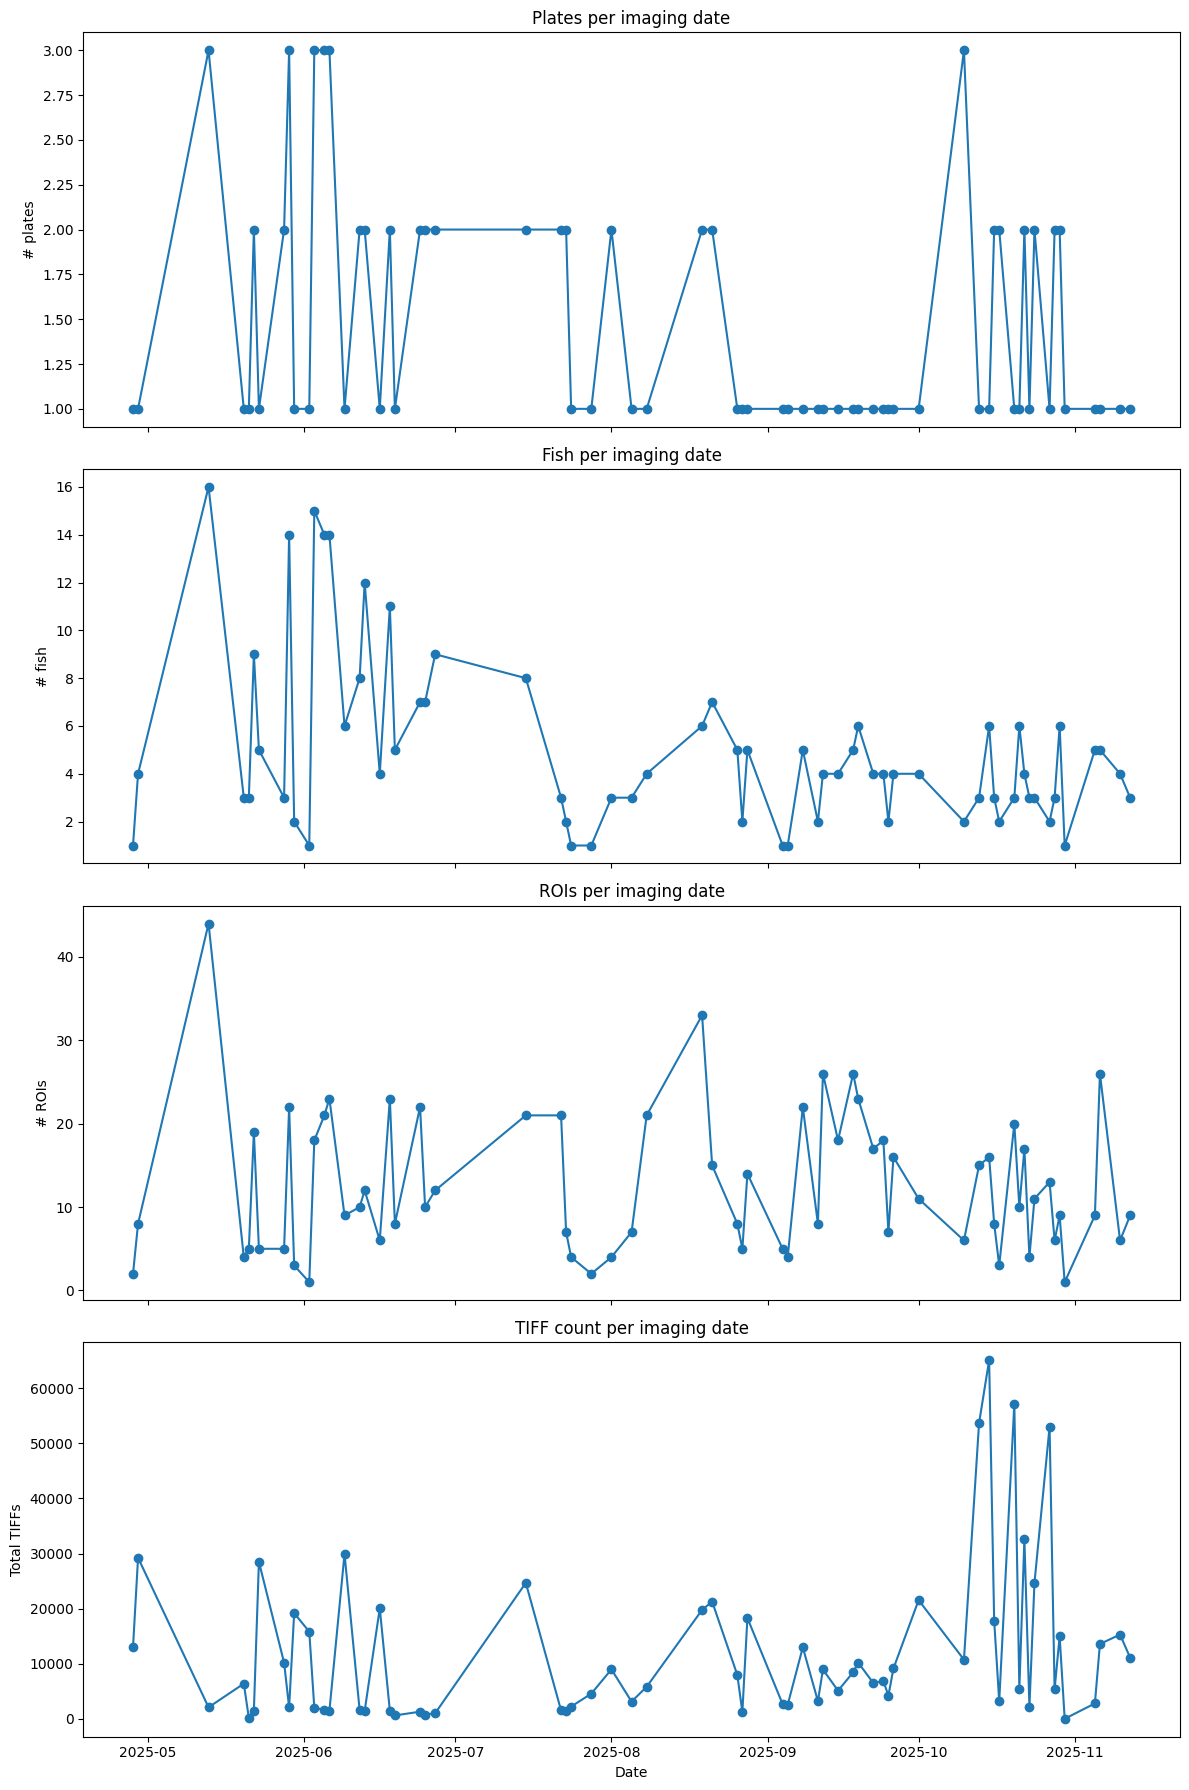

In [26]:
# V9-10 — Per-date QC with markers (plates, fish, ROIs, TIFFs)

import matplotlib.pyplot as plt
import pandas as pd

df_dates = df_enrich.copy()

# Ensure date column is datetime
df_dates["date_imaged"] = pd.to_datetime(df_dates["Date imaged"], errors="coerce")

# Drop rows with no date
df_dates = df_dates[df_dates["date_imaged"].notna()]

# Aggregate per date
by_day = df_dates.groupby(df_dates["date_imaged"].dt.date)
plates_per_day = by_day["plate_id_filled"].nunique()
fish_per_day   = by_day["fish_id"].nunique()
rois_per_day   = by_day.size()
tiffs_per_day  = by_day["roi_tiffs"].sum()

fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)

axes[0].plot(plates_per_day.index, plates_per_day.values, marker="o")
axes[0].set_title("Plates per imaging date")
axes[0].set_ylabel("# plates")

axes [1].plot(fish_per_day.index, fish_per_day.values, marker="o")
axes[1].set_title("Fish per imaging date")
axes[1].set_ylabel("# fish")

axes[2].plot(rois_per_day.index, rois_per_day.values, marker="o")
axes[2].set_title("ROIs per imaging date")
axes[2].set_ylabel("# ROIs")

axes[3].plot(tiffs_per_day.index, tiffs_per_day.values, marker="o")
axes[3].set_title("TIFF count per imaging date")
axes[3].set_ylabel("Total TIFFs")
axes[3].set_xlabel("Date")

plt.tight_layout()
plt.show()

V9-11 — combo counts for all_unique_organelles (top 50):
all_unique_organelles
membrane|mitochondria               369
cytosol                             260
membrane|histone                    163
actin                                42
ER|mitochondria                      26
mitochondria                         26
ER                                   23
mitochondria|lysosome                18
membrane|Peroxisome                  11
actin|mitochondria                    5
membrane|mitochondria|ER              4
membrane|histone|mitochondria         4
lysosome|mitochondria                 3
membrane|histone|cytosol|nucleus      3
cytosol|nucleus                       3
Nuclear Envelope                      2
membrane|ER|mitochondria              1
membrane|Kinetochore                  1
Microtubule EBP                       1
Name: count, dtype: Int64


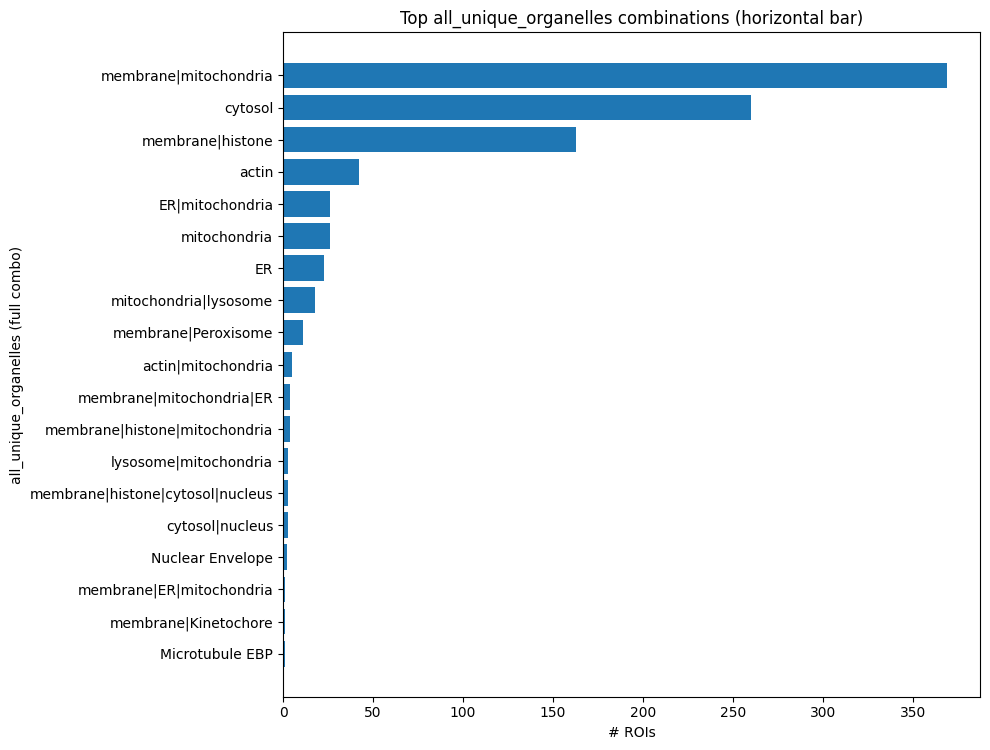


V9-11 — combo counts for all_fluor_organelles (top 50):
all_fluor_organelles
tdmChilada(membrane)|mStayGold(mitochondria)                                        367
mKate2(cytosol)|mCitrine(cytosol)|Electra2(cytosol)|mKOK(cytosol)|mTFP1(cytosol)    252
tdmSG(membrane)|tdmScarlet3(histone)                                                131
mStayGold(actin)                                                                     42
tdmSG(membrane)|tdmScarlet3(histone)|mScarlet3S2(histone)                            32
mStayGold(mitochondria)                                                              26
mStayGold(ER)                                                                        23
mStayGold(mitochondria)|mStayGold(lysosome)                                          18
Halo(ER)|mScarlet3S2(ER)|mScarlet3S2(mitochondria)|Halo(mitochondria)                17
tdmScarlet3(membrane)|mStayGold(Peroxisome)                                          11
mGold2s(cytosol)                          

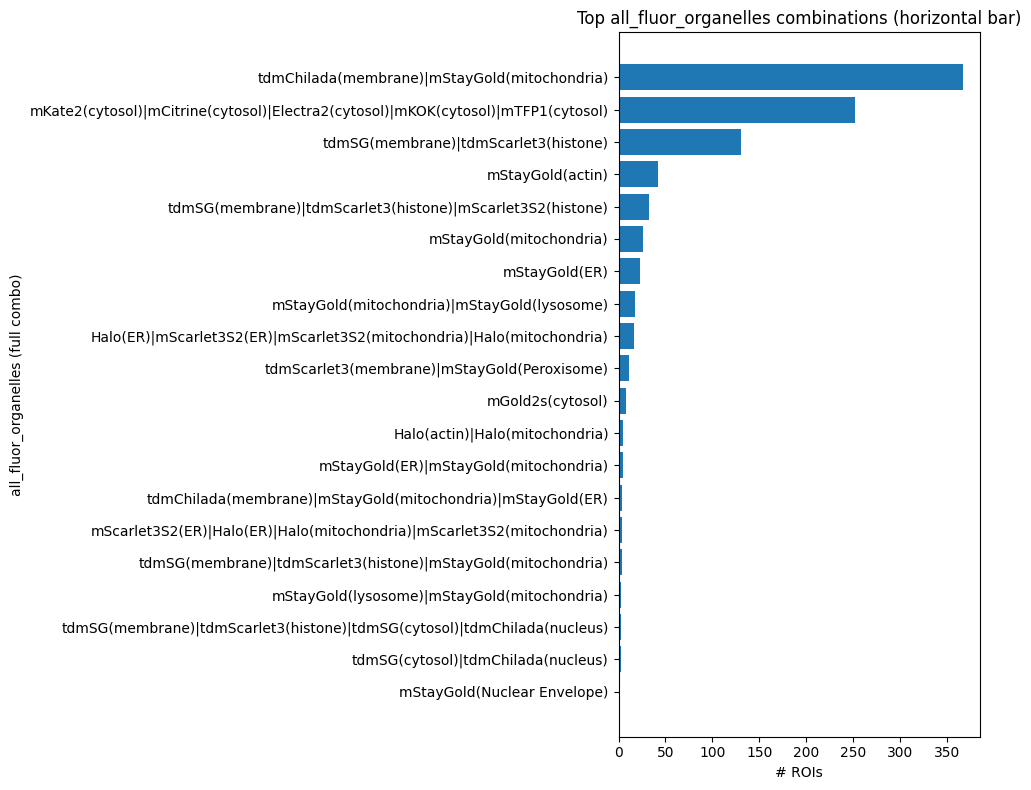

In [27]:
# V9-11 — combo distributions of full organelle & fluor-organelles (horizontal bar charts)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "df_for_db_v9" not in globals():
    raise NameError("V9-11: df_for_db_v9 not found; run V9-06+ cells first.")

df_combo = df_for_db_v9.copy()

# Ensure relevant columns are string-typed
for col in ["all_unique_organelles", "all_fluor_organelles"]:
    if col in df_combo.columns:
        df_combo[col] = df_combo[col].astype("string")

def _valid_series(s: pd.Series) -> pd.Series:
    """Mask of non-empty, non-NA strings."""
    return s.notna() & (s.str.strip() != "") & (s.str.lower() != "<na>")

# ---- 1) Full combo frequencies for all_unique_organelles ----
if "all_unique_organelles" in df_combo.columns:
    uni_raw = df_combo.loc[_valid_series(df_combo["all_unique_organelles"]),
                           "all_unique_organelles"]
    uni_counts = uni_raw.value_counts().sort_values(ascending=False)

    print("V9-11 — combo counts for all_unique_organelles (top 50):")
    print(uni_counts.head(50))

    top_uni = uni_counts.head(20)
    if not top_uni.empty:
        y_pos = np.arange(len(top_uni))
        plt.figure(figsize=(10, max(4, 0.4 * len(top_uni))))
        plt.barh(y_pos, top_uni.values)
        plt.yticks(y_pos, top_uni.index)
        plt.xlabel("# ROIs")
        plt.ylabel("all_unique_organelles (full combo)")
        plt.title("Top all_unique_organelles combinations (horizontal bar)")
        plt.gca().invert_yaxis()  # largest at top
        plt.tight_layout()
        plt.show()
    else:
        print("No non-empty all_unique_organelles combos to plot.")
else:
    print("V9-11 — Column 'all_unique_organelles' not found in df_for_db_v9")

# ---- 2) Full combo frequencies for all_fluor_organelles ----
if "all_fluor_organelles" in df_combo.columns:
    fl_raw = df_combo.loc[_valid_series(df_combo["all_fluor_organelles"]),
                          "all_fluor_organelles"]
    fl_counts = fl_raw.value_counts().sort_values(ascending=False)

    print("\nV9-11 — combo counts for all_fluor_organelles (top 50):")
    print(fl_counts.head(50))

    top_fl = fl_counts.head(20)
    if not top_fl.empty:
        y_pos = np.arange(len(top_fl))
        plt.figure(figsize=(10, max(4, 0.4 * len(top_fl))))
        plt.barh(y_pos, top_fl.values)
        plt.yticks(y_pos, top_fl.index)
        plt.xlabel ("# ROIs")
        plt.ylabel("all_fluor_organelles (full combo)")
        plt.title("Top all_fluor_organelles combinations (horizontal bar)")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("No non-empty all_fluor_organelles combos to plot.")
else:
    print("V9-11 — Column 'all_fluor_organelles' not found in df_for_db_v9")

In [28]:
# V9-QC1 — Compare date prefix from experiment_folder vs imaging-sheet date_mount

import pandas as pd
import re

df = df_enrich.copy()

def extract_date_prefix(exp_folder):
    if pd.isna(exp_folder):
        return None
    m = re.match(r"(\d{8})", str(exp_folder))
    return m.group(1) if m else None

df["date_mount_from_exp"] = df["experiment_folder"].apply(extract_date_prefix)
df["date_mount_from_sheet"] = df["date_mount_yyyymmdd"].astype("Int64").astype(str)

# QC: mismatches between the two dates
mismatch = df[
    df["date_mount_from_exp"].notna()
    & df["date_mount_from_sheet"].notna()
    & (df["date_mount_from_exp"] != df["date_mount_from_sheet"])
]

print("V9-QC1 — Date prefix mismatches:", len(mismatch))
mismatch[
    ["roi_dir", "experiment_folder", "date_mount_from_exp", "date_mount_from_sheet"]
].head(50)

V9-QC1 — Date prefix mismatches: 144


,roi_dir,experiment_folder,date_mount_from_exp,date_mount_from_sheet
0,/clusterfs/vast/abcabc/Aang_Foundation/2025072...,20250721_72hpf_mrna_mSG_organelle_LLS-SIM,20250721,<NA>
1,/clusterfs/vast/abcabc/Aang_Foundation/2025072...,20250721_72hpf_mrna_mSG_organelle_LLS-SIM,20250721,<NA>
2,/clusterfs/vast/abcabc/Aang_Foundation/2025072...,20250721_72hpf_mrna_mSG_organelle_LLS-SIM,20250721,<NA>
3,/clusterfs/vast/abcabc/Aang_Foundation/2025072...,20250721_72hpf_mrna_mSG_organelle_LLS-SIM,20250721,<NA>
4,/clusterfs/vast/abcabc/Aang_Foundation/2025072...,20250721_72hpf_mrna_mSG_organelle_LLS-SIM,20250721,<NA>
26,/clusterfs/vast/abcabc/Aang_Foundation/2025072...,20250723_er-mSG_mem-mChilada,20250723,<NA>
27,/clusterfs/vast/abcabc/Aang_Foundation/2025080...,20250805_lifeact_mem-halo,20250805,<NA>
28,/clusterfs/vast/abcabc/Aang_Foundation/2025080...,20250805_lifeact_mem-halo,20250805,<NA>
29,/clusterfs/vast/abcabc/Aang_Foundation/2025080...,20250805_lifeact_mem-halo,20250805,<NA>
30,/clusterfs/vast/abcabc/Aang_Foundation/2025080...,20250805_lifeact_mem-halo,20250805,<NA>


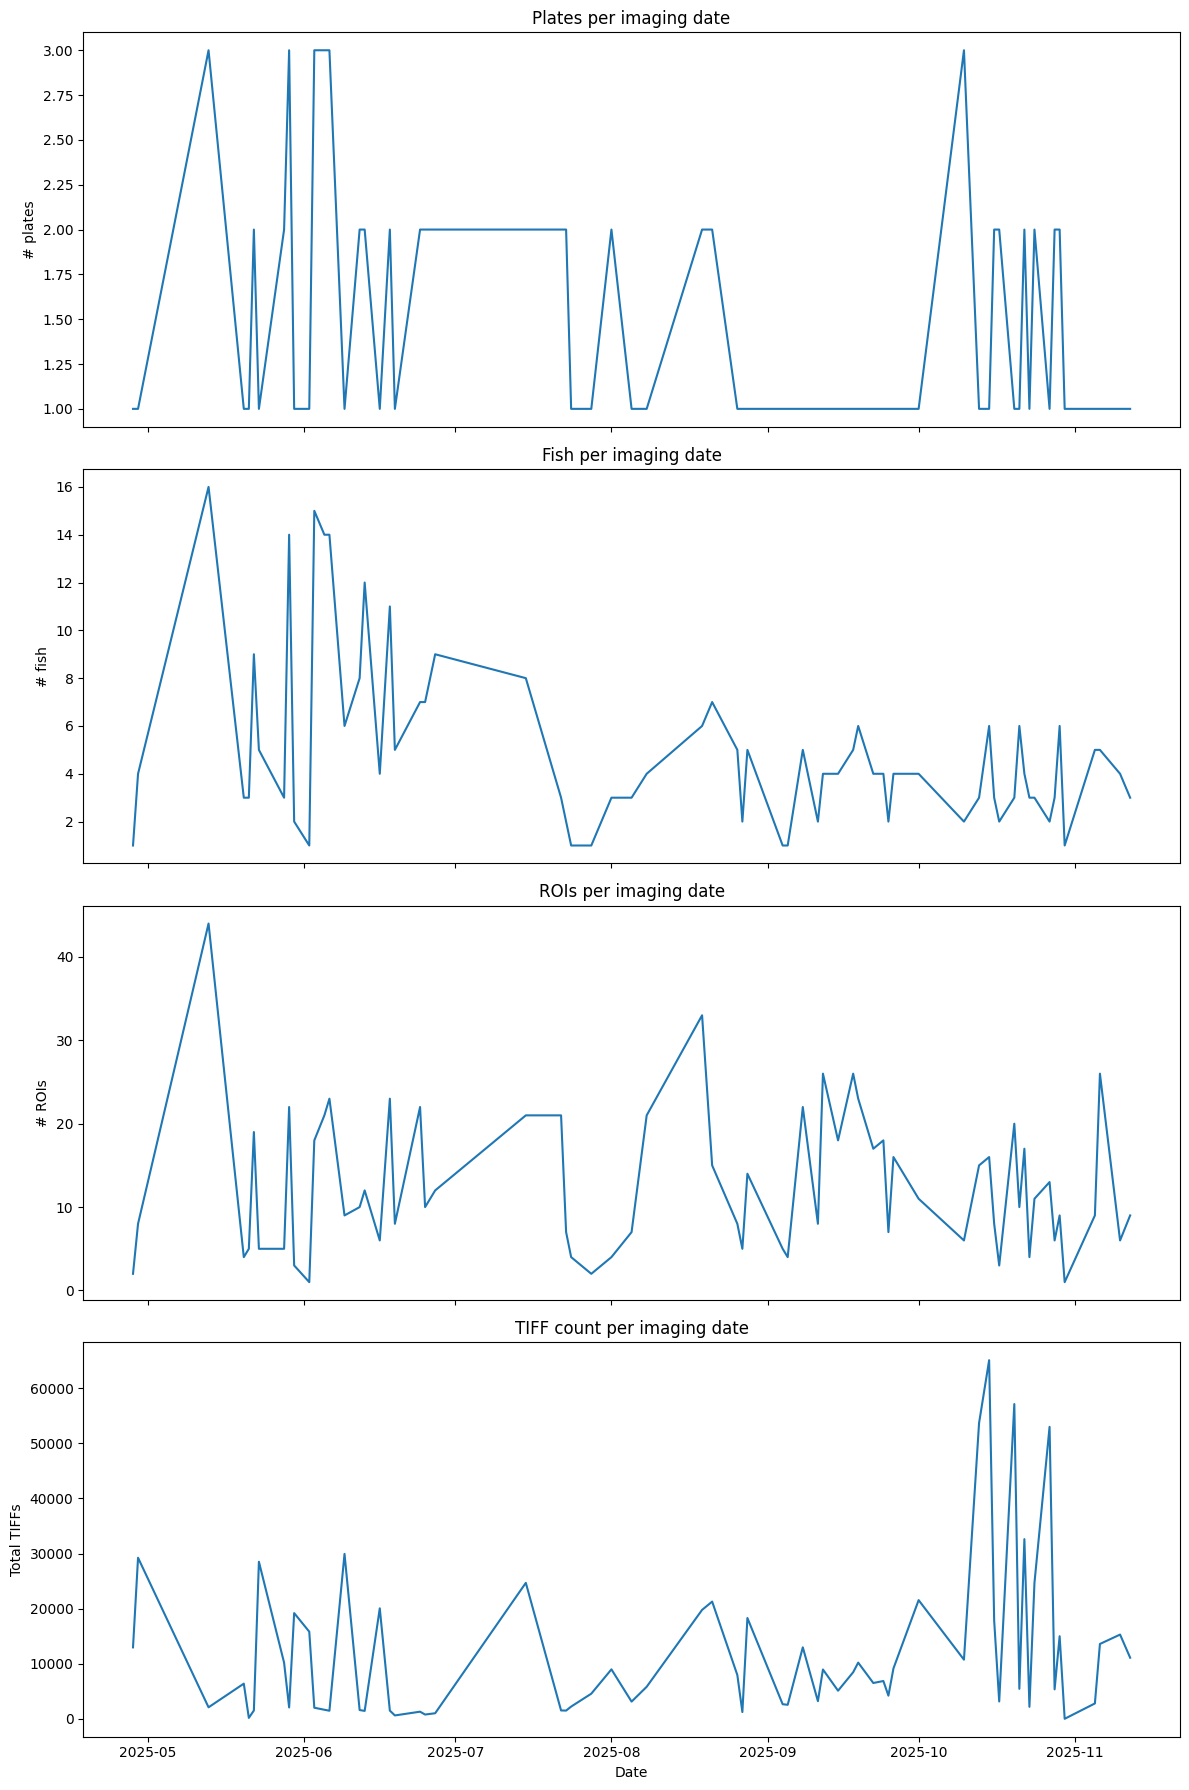

In [29]:
# V9-QC2 — summary plots per imaging date

import matplotlib.pyplot as plt

df = df_enrich.copy()

# Clean date column
df["date_imaged"] = pd.to_datetime(df["Date imaged"], errors="coerce")

# Aggregations
plates_per_day = df.groupby(df["date_imaged"].dt.date)["plate_id_filled"].nunique()
fish_per_day   = df.groupby(df["date_imaged"].dt.date)["fish_id"].nunique()
rois_per_day   = df.groupby(df["date_imaged"].dt.date).size()
tiffs_per_day  = df.groupby(df["date_imaged"].dt.date)["roi_tiffs"].sum()


fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)

axes[0].plot(plates_per_day.index, plates_per_day.values)
axes[0].set_title("Plates per imaging date")
axes[0].set_ylabel("# plates")

axes[1].plot(fish_per_day.index, fish_per_day.values)
axes[1].set_title("Fish per imaging date")
axes[1].set_ylabel("# fish")

axes[2].plot(rois_per_day.index, rois_per_day.values)
axes[2].set_title("ROIs per imaging date")
axes[2].set_ylabel("# ROIs")

axes[3].plot(tiffs_per_day.index, tiffs_per_day.values)
axes[3].set_title("TIFF count per imaging date")
axes[3].set_ylabel("Total TIFFs")
axes[3].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [30]:
# V9-QC3 — organelle distribution

df = df_enrich.copy()

# Split pipe lists into long-form rows
def explode_pipe(df, col):
    return (
        df[[col]]
        .dropna()
        .assign(**{col: lambda x: x[col].str.split("|")})
        .explode(col)
        .assign(**{col: lambda x: x[col].str.strip()})
        .query(f"{col} != ''")
    )

uni_org = explode_pipe(df, "all_unique_organelles")
flu_org = explode_pipe(df, "all_fluor_organelles")

print("V9-QC3 — counts of all_unique_organelles:")
print(uni_org["all_unique_organelles"].value_counts().head(50))

print("\nV9-QC3 — counts of all_fluor_organelles:")
print(flu_org["all_fluor_organelles"].value_counts().head(50))

V9-QC3 — counts of all_unique_organelles:
all_unique_organelles
membrane            556
mitochondria        456
cytosol             266
histone             170
ER                   54
actin                47
lysosome             21
Peroxisome           11
nucleus               6
Nuclear Envelope      2
Kinetochore           1
Microtubule EBP       1
Name: count, dtype: int64

V9-QC3 — counts of all_fluor_organelles:
all_fluor_organelles
mStayGold(mitochondria)        429
tdmChilada(membrane)           374
mTFP1(cytosol)                 252
mKOK(cytosol)                  252
Electra2(cytosol)              252
mCitrine(cytosol)              252
mKate2(cytosol)                252
tdmSG(membrane)                171
tdmScarlet3(histone)           170
mStayGold(actin)                42
mStayGold(ER)                   33
mScarlet3S2(histone)            32
Halo(mitochondria)              27
mStayGold(lysosome)             21
Halo(ER)                        21
mScarlet3S2(ER)                 21

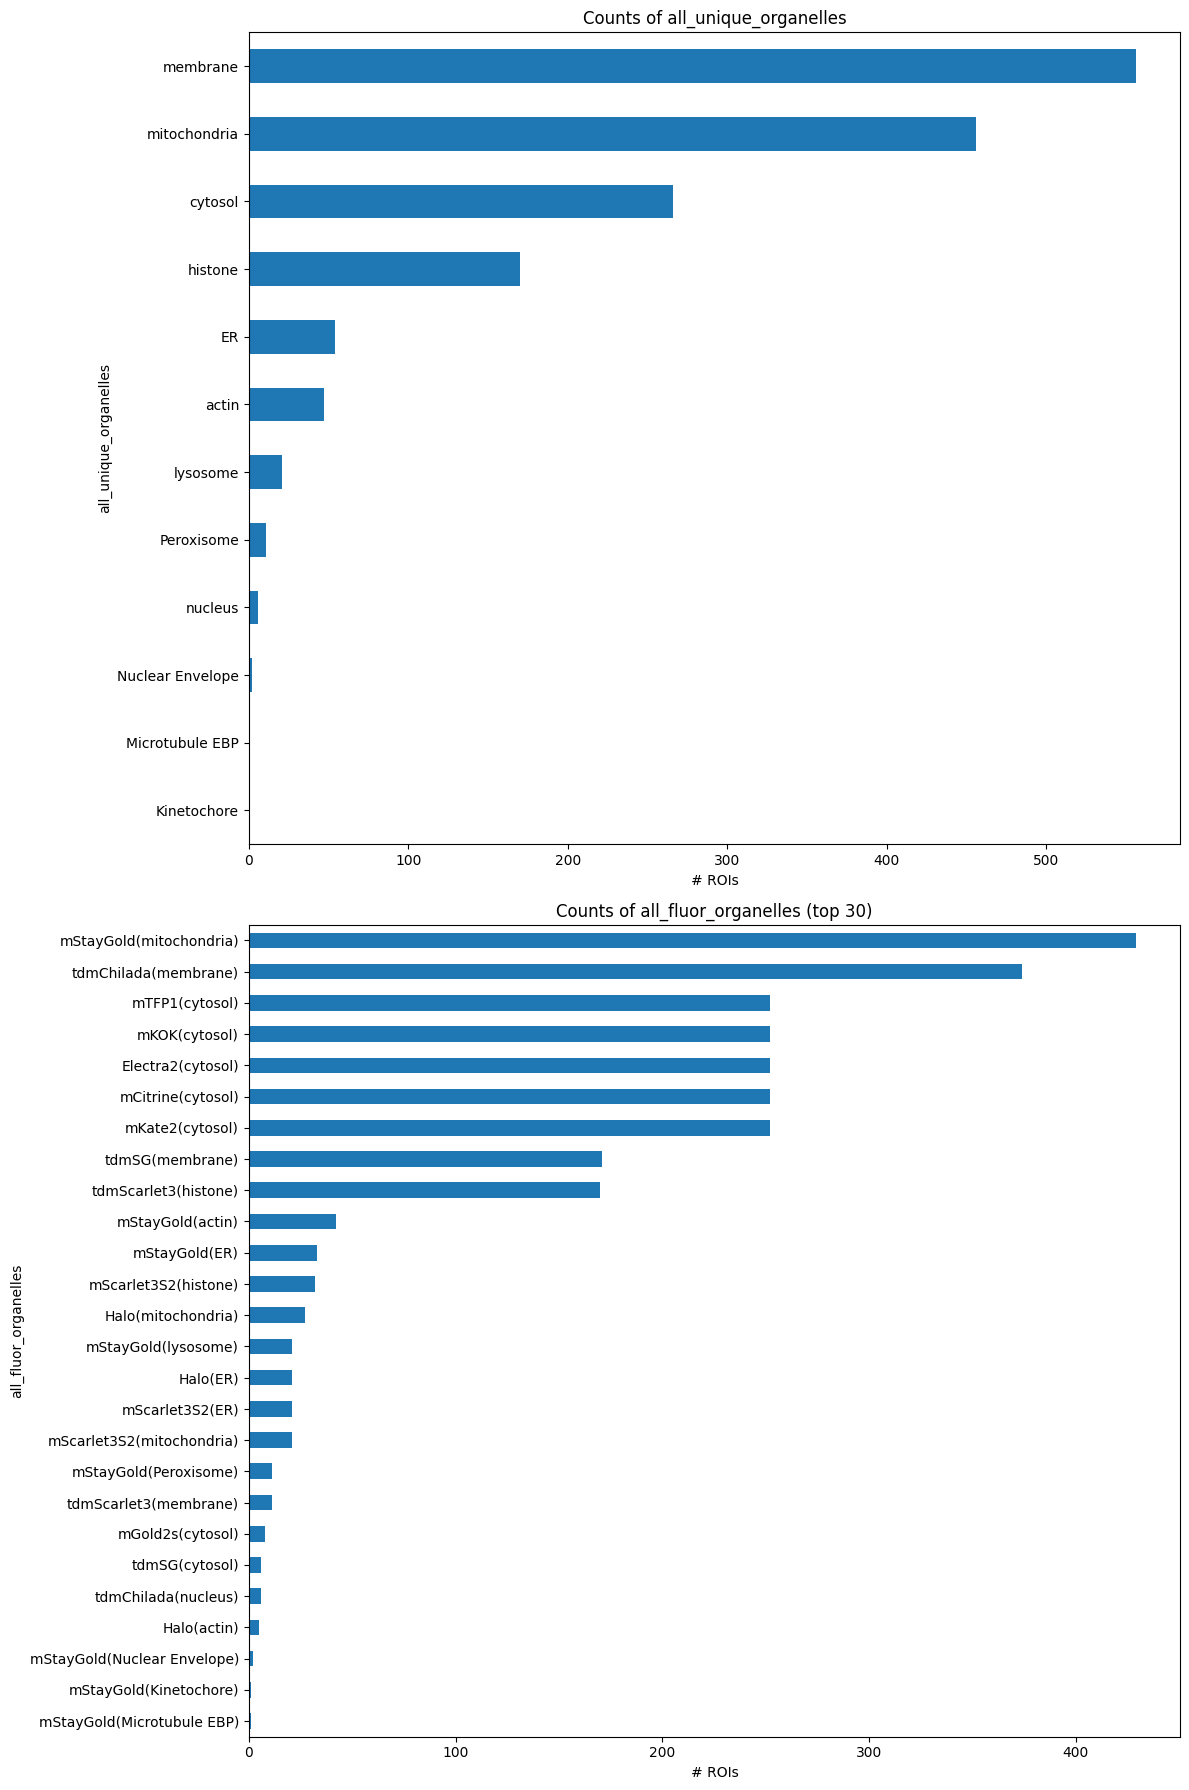

In [31]:
# V9-QC3b — organelle count plots

import matplotlib.pyplot as plt

uni_counts = uni_org["all_unique_organelles"].value_counts().sort_values()
flu_counts = flu_org["all_fluor_organelles"].value_counts().sort_values().head(30)

fig, axes = plt.subplots(2, 1, figsize=(12, 18))

uni_counts.plot.barh(ax=axes[0])
axes[0].set_title("Counts of all_unique_organelles")
axes[0].set_xlabel("# ROIs")

flu_counts.plot.barh(ax=axes[1])
axes[1].set_title("Counts of all_fluor_organelles (top 30)")
axes[1].set_xlabel("# ROIs")

plt.tight_layout()
plt.show()